In [137]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from scipy.linalg import norm
from itertools import islice, cycle
import matplotlib
from qsmp import tree
from ipywidgets import interact, fixed
from pathlib import Path

In [138]:
colors = np.array(["#377eb8", "#ff7f00", "#4daf4a", "#f781bf", "#a65628", "#984ea3", "#999999", "#e41a1c", "#dede00", "#000000"])
len(colors)
plt.rcParams.update({
    "text.usetex": True,    
    "font.size": 12
})
img_dir = Path('../results/img/')

In [3]:
def QuickShift(X, sigma, max_dist):
    
    # Pair-wise distance matrix
    Dmat = euclidean_distances(X, squared=True)
    
    # Density estimation
    density = np.exp(-0.5*Dmat/sigma**2)
    density = np.sum(density, axis=1)
    
    # Find nearest-neighbor with higher density
    NNindex = np.full(n_samples, -1)
    NNdist = np.full(n_samples, np.inf)
    for i in range(n_samples):
        higher_density = (density > density[i]).nonzero()[0]
        if higher_density.size > 0:
            j_min = np.argmin(Dmat[i, higher_density])
            j_min = higher_density[j_min]
            NNindex[i] = j_min
            NNdist[i] = Dmat[i, j_min]

    # Clean global maxima
    i_max = np.argmax(density)
    iinf = (np.isinf(NNdist)).nonzero()[0]
    assert i_max in iinf
    NNdist[iinf] = 0
    NNindex[iinf] = iinf
    
    NNindex, NNdist = tree.cut_tree(
        NNindex, NNdist, max_dist)

    # Assign each subsequence to its root: clustering
    NNindex = tree.mark_with_root(NNindex)
          
    return density, NNdist, NNindex

In [4]:
def get_cluster_labels(NNindex):
    unique_roots, inv_ind, num_nodes = np.unique(
            NNindex, return_inverse=True, return_counts=True)

    outliers_idx = (num_nodes == 1).nonzero()[0]
    for i in outliers_idx:
        inv_ind[inv_ind == i] = 9 # cluster with label 9 is colored as black
    
    return inv_ind

In [99]:
def show_clusters(fig, ax, X, y_pred):
    
    limsc = 1.1
    x_grid = X[:,0]
    y_grid = X[:,1]
        
    ax.scatter(X[:,0], X[:,1], s=10, color=colors[y_pred])
          
    ax.set_ylim([limsc*X[:,1].min(), limsc*X[:,1].max()])
    ax.set_xlim([limsc*X[:,0].min(), limsc*X[:,0].max()])    

In [56]:
def quickShift_demo(dataset, sigma, max_dist):
    
    n_samples = 500
    if dataset == "blobs":
        data = datasets.make_blobs(
            n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], 
            random_state=13)
    elif dataset == "moons":
        data = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=13)    
    
    X, y = data
    density, NNdist, NNindex = QuickShift(X, sigma=sigma, max_dist=max_dist)
    y_pred = get_cluster_labels(NNindex)
    show_clusters(X, y_pred)

In [57]:
interact(
    quickShift_demo,
    dataset=['moons', 'blobs'],
    sigma=(0.1, 2.0),
    max_dist=(0.1, 3)
)

interactive(children=(Dropdown(description='dataset', options=('moons', 'blobs'), value='moons'), FloatSlider(…

<function __main__.quickShift_demo(dataset, sigma, max_dist)>

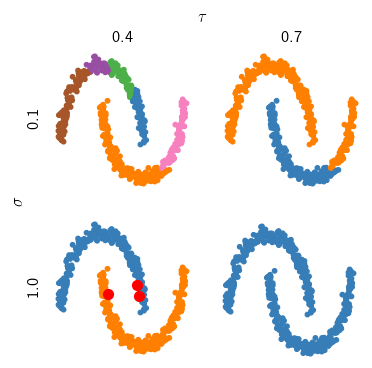

In [208]:
n_samples = 500
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=13)
X, y = noisy_moons
x_grid = X[:,0]
y_grid = X[:,1]
sigma = np.r_[0.1, 1]
max_dist = np.r_[0.4, 0.7]
n_sigmas, n_dists = sigma.size, max_dist.size
fig, ax = plt.subplots(n_dists, n_sigmas, figsize=(2*n_sigmas, 2*n_dists))
limsc = 1.1
for i, s in enumerate(sigma):
    for j, d in enumerate(max_dist):
        density, NNdist, NNindex = QuickShift(X, sigma=s, max_dist=d)
        y_pred = get_cluster_labels(NNindex)
        
        ax[i,j].scatter(X[:,0], X[:,1], s=10, color=colors[y_pred])
        ax[i,j].set_frame_on(False)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])
        plt.ylim([limsc*X[:,1].min(), limsc*X[:,1].max()])
        plt.xlim([limsc*X[:,0].min(), limsc*X[:,0].max()])        
               
        if i == 0:
            ax[i,j].set_title(f'{d:.1f}', fontsize=12)
        if j == 0:
            ax[i,j].set_ylabel(f'{s:.1f}', fontsize=12)
            
        if i == 1 and j == 0:
            isort = np.argsort(-density)
            top_modes = 3
            ax[i,j].scatter(X[isort[:top_modes],0],X[isort[:top_modes],1], s=50, marker='o', color= 'red')

fig.supylabel(r'$\sigma$', fontsize=12)
fig.suptitle(r'$\tau$', fontsize=12)
fpath = img_dir.joinpath('two-moons_quick-shift-demo.pdf')
fig.savefig(fpath, bbox_inches='tight', pad_inches=0)

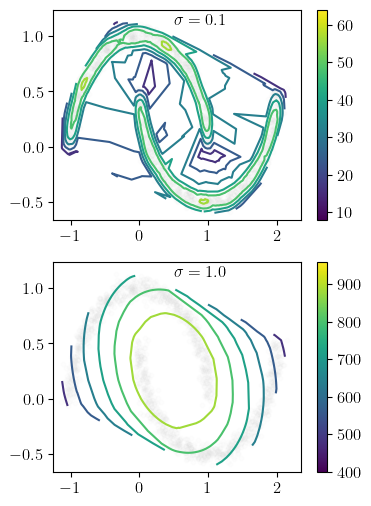

In [197]:
n_samples = 1500
markers = np.array(["x", "d", "s", "+", "o", ">"])
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=13)
X, y = noisy_moons
fig, ax = plt.subplots(2,1, figsize=(4, 6))

density, NNdist, NNindex = QuickShift(X, sigma=0.1, max_dist=0.4)
y_pred = get_cluster_labels(NNindex)

limsc = 1.1
x_grid = X[:,0]
y_grid = X[:,1]

# unique_labels = np.unique(y_pred)
# for label in unique_labels:
    # idx = y_pred == label
ax[0].scatter(X[:,0], X[:,1], s=10, color=colors[6], alpha=0.01)

ax[0].set_ylim([limsc*X[:,1].min(), limsc*X[:,1].max()])
ax[0].set_xlim([limsc*X[:,0].min(), limsc*X[:,0].max()]) 

# isort = np.argsort(-density)
# top_modes = 4
# plt.scatter(X[isort[:top_modes],0],X[isort[:top_modes],1], s=50, marker='o', color= 'red')
ax[0].annotate(r'$\sigma=0.1$', xy=(0.5, 1.1))
cl = ax[0].tricontour(x_grid, y_grid, density, cmap='viridis')
norm = matplotlib.colors.Normalize(vmin=cl.cvalues.min(), vmax=cl.cvalues.max())        
sm = plt.cm.ScalarMappable(norm=norm, cmap=cl.cmap)
plt.colorbar(sm, ax=ax[0])

##########
density, NNdist, NNindex = QuickShift(X, sigma=1, max_dist=0.4)
y_pred = get_cluster_labels(NNindex)

limsc = 1.1
x_grid = X[:,0]
y_grid = X[:,1]

# unique_labels = np.unique(y_pred)
# for label in unique_labels:
    # idx = y_pred == label
ax[1].scatter(X[:,0], X[:,1], s=10, color=colors[6], alpha=0.01)

ax[1].set_ylim([limsc*X[:,1].min(), limsc*X[:,1].max()])
ax[1].set_xlim([limsc*X[:,0].min(), limsc*X[:,0].max()]) 

# isort = np.argsort(-density)
# top_modes = 4
# plt.scatter(X[isort[:top_modes],0],X[isort[:top_modes],1], s=50, marker='o', color= 'red')
ax[1].annotate(r'$\sigma=1.0$', xy=(0.5, 1.1))
cl = ax[1].tricontour(x_grid, y_grid, density, cmap='viridis')
norm = matplotlib.colors.Normalize(vmin=cl.cvalues.min(), vmax=cl.cvalues.max())        
sm = plt.cm.ScalarMappable(norm=norm, cmap=cl.cmap)
plt.colorbar(sm, ax=ax[1])

fpath = img_dir.joinpath('two-moons_quick-shift-demo_contours.pdf')
fig.savefig(fpath, bbox_inches='tight', pad_inches=0)

In [207]:
n_samples = 500
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=13)
X, _ = noisy_moons
density, NNdist, NNindex = QuickShift(X, sigma=1, max_dist=0.4)
y_pred = get_cluster_labels(NNindex)

In [206]:
density[124], density[319], np.unique(NNindex)

(310.9863644068736, 310.1693645945729, array([124, 319]))